In [6]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import sys
sys.path.append("/var/home/maxpetzold/HUB_local/")

import pandas as pd
from scipy.stats import pearsonr

from codebase.src.plots.pyplot import PyPlots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
path_df = "../data/dry_weight/pflanzen_incl_ratio.csv"

In [8]:
df = pd.read_csv(path_df)
df.head()

,Nr,Spross,Wurzel,ratio
0,1,13.3,8.8,0.601810
1,2,27.1,9.9,0.732432
2,3,0.9,0.3,0.750000
3,4,10.0,5.5,0.645161
4,5,11.8,4.2,0.737500


$\Large\bullet \text{ Histograms of sprout, root and their ratio}$

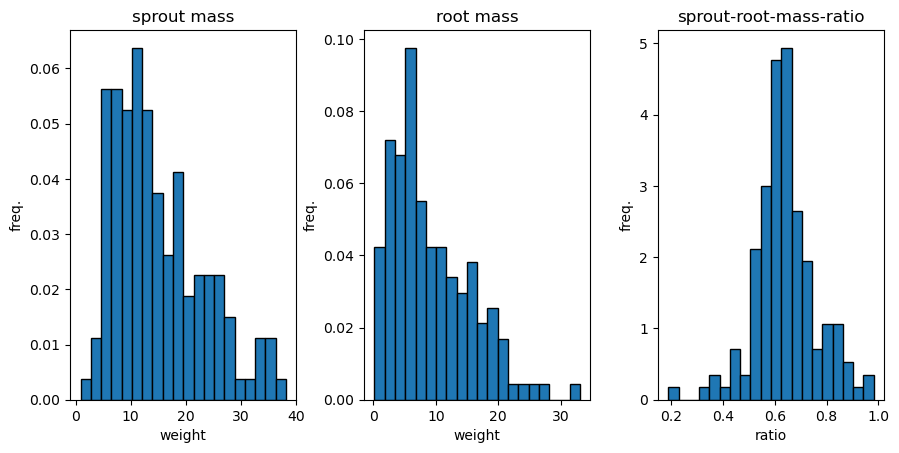

In [9]:
histograms = PyPlots(1,3)

histograms.hist(i = 0, j = 0, x = df["Spross"], title = "sprout mass", 
                xlabel="weight", ylabel = "freq.", bins = 20)

histograms.hist(i = 0, j = 1, x = df["Wurzel"], title = "root mass", 
               xlabel="weight", ylabel = "freq.", bins = 20)

histograms.hist(i = 0, j = 2, x = df["ratio"], title = "sprout-root-mass-ratio", 
                xlabel="ratio", ylabel = "freq.", bins = 20)

histograms.display()
histograms.savefig(fname="01_histograms.png", dpi=140)

### Weights Distribution
$\bullet$ This weights of sprouts and roots tend to be slightly right skewed (rechtsschief)  
$\bullet$ $Weights \in \mathbb{R}_+$   
$\bullet$ Just a normal distriution might now be appropiate, because its highly likely it will extend into the negatives and doesnt catch the skewness  
$\bullet$ A Gamma might fits the marginal distribution better, because: $X \in \mathbb{R}_{+}$

### Ratio distribution
$\bullet$ The skweness seem to not be present here   
$\bullet$ $Ratio \in [0, 1]$    
$\bullet$ Intuitivly (and by their definition) a beta might fit best here  

$\Large\bullet \text{ Correlation sprout and roots weigths}$

PearsonRResult(statistic=np.float64(0.7636647486847383), pvalue=np.float64(1.4047634444631887e-28))


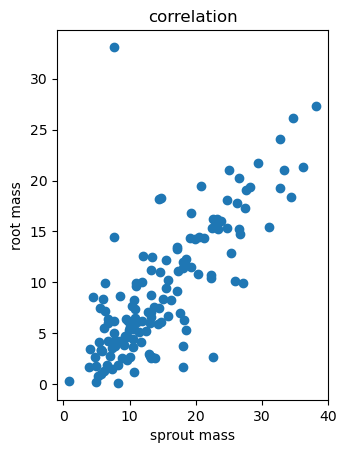

In [11]:
print(pearsonr(df.Spross, df.Wurzel))
correlation = PyPlots(1,1)
correlation.scatter(0,0, x=df.Spross, y=df.Wurzel, title="correlation", xlabel="sprout mass", ylabel="root mass")
correlation.display()
correlation.savefig("01_correlation.png", dpi=140)

### Correlation  
- Hight correlation between their weights 
- Implying a statistical depency between both parameters !!!